# Daily Embedding Classifier — Home Ventilator Data (First 7 Days)

**Goal**: Compress each patient-day into a 32/64/128-dim embedding using a shared Transformer,
then classify label 0 vs label 1 using XGBoost / Random Forest per day.

**Pipeline**:
```
Raw readings (per 24k-row chunk per patient per unified_day)
  → Shared Transformer Encoder  (BCE loss, patient-level label)
  → N-dim chunk embedding  (N = 32, 64, 128 — trained separately)
  → Average chunks → 1 embedding per (patient, unified_day)
  → XGBoost / RF on N-dim features → label 0 or 1 per row
  → Results table: rows=patients, columns=days
```

**Data**: first 7 days of monitoring per patient
- unified_day 0 = first day of monitoring (from start_date)
- unified_day 6 = 7th day of monitoring
- No countdown_days_target — unified_day computed from start_date forwards


---
## Step 1 — Install & Import

In [1]:
!pip install -q xgboost scikit-learn

In [2]:
import os
import gc
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import GradScaler, autocast
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from collections import Counter, defaultdict
from matplotlib.colors import LinearSegmentedColormap
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.10.0+cu128


---
## Step 2 — Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/first7days_rawdata_label0&1_parquet"

# Load only needed columns to save RAM
LOAD_COLS = [
    'patient_id', 'label', 'time_from_start_seconds',
    'test_type', 'test_value_scaled',
    'hour_of_day_scaled', 'collection'
]

df_train = pd.read_parquet(os.path.join(ROOT, 'train.parquet'), columns=LOAD_COLS)
df_val   = pd.read_parquet(os.path.join(ROOT, 'val.parquet'),   columns=LOAD_COLS)
df_test  = pd.read_parquet(os.path.join(ROOT, 'test.parquet'),  columns=LOAD_COLS)

print(f'Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}')
print(f'Columns: {df_train.columns.tolist()}')
for name, df in [('train',df_train),('val',df_val),('test',df_test)]:
    print(f'  {name}: {df.memory_usage(deep=True).sum()/1024**3:.2f} GB')
df_train.head(3)


Mounted at /content/drive
Train: 75,343,005  |  Val: 18,755,025  |  Test: 28,258,699
Columns: ['patient_id', 'label', 'time_from_start_seconds', 'test_type', 'test_value_scaled', 'hour_of_day_scaled', 'collection']
  train: 10.46 GB
  val: 2.57 GB
  test: 3.90 GB


,patient_id,label,time_from_start_seconds,test_type,test_value_scaled,hour_of_day_scaled,collection
0,2,0,0.2,flow,0.381711,0.541667,train
1,2,0,0.2,pressure,0.024769,0.541667,train
2,2,0,0.4,pressure,0.026136,0.541667,train


---
## Step 3 — Build unified_day, Drop Bad Patients, Trim Columns

**unified_day (0..6, first 7 days)**:
- No `countdown_days_target` in first-7-days data — computed from `start_date` forwards
- Both Label 0 and Label 1: `days_from_start = timestamp - start_date`
  - unified_day 0 = first day of monitoring
  - unified_day 6 = 7th day of monitoring
  - Rows beyond day 6 are dropped

**Drop**: patient 68 — only 3 days of data.

**Trim**: keep only columns needed for training to save RAM.


In [4]:
# ── Drop insufficient patients ───────────────────────────────────────────────
PATIENTS_TO_DROP = [68]
for df in [df_train, df_val, df_test]:
    mask = df['patient_id'].isin(PATIENTS_TO_DROP)
    df.drop(df[mask].index, inplace=True)
print(f'Dropped patients: {PATIENTS_TO_DROP}')

# ── Build unified_day (0..6) from time_from_start_seconds ────────────────────
# day 0 = first day, day 6 = 7th day; 86400 seconds = 1 day
def add_unified_day(df):
    days_from_start = (df['time_from_start_seconds'] / 86400).astype(int)
    df['unified_day'] = days_from_start
    drop_idx = df[~df['unified_day'].between(0, 6)].index
    df.drop(drop_idx, inplace=True)
    df['unified_day'] = df['unified_day'].astype(int)

print('\nAdding unified_day (first-7-days, forward from time_from_start_seconds)...')
add_unified_day(df_train); gc.collect()
add_unified_day(df_val);   gc.collect()
add_unified_day(df_test);  gc.collect()

# ── Compute time_from_start_scaled (fit on train only) ───────────────────────
from sklearn.preprocessing import MinMaxScaler
tfs_scaler = MinMaxScaler()
df_train['time_from_start_scaled'] = tfs_scaler.fit_transform(df_train[['time_from_start_seconds']])
df_val['time_from_start_scaled']   = tfs_scaler.transform(df_val[['time_from_start_seconds']])
df_test['time_from_start_scaled']  = tfs_scaler.transform(df_test[['time_from_start_seconds']])
print(f'  time_from_start_scaled range (train): '
      f'{df_train["time_from_start_scaled"].min():.4f} – '
      f'{df_train["time_from_start_scaled"].max():.4f}')

# ── Keep only columns needed — drop time_from_start_seconds immediately ───────
KEEP_COLS = ['patient_id', 'label', 'unified_day',
             'test_type', 'test_value_scaled',
             'hour_of_day_scaled', 'time_from_start_scaled', 'collection']

for df, name in [(df_train,'train'), (df_val,'val'), (df_test,'test')]:
    drop_cols = [c for c in df.columns if c not in KEEP_COLS]
    df.drop(columns=drop_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    gc.collect()
    print(f'{name:>6}: {len(df):,} rows  {df.memory_usage(deep=True).sum()/1024**3:.2f} GB')

all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
print('\n=== unified_day distribution by label ===')
print(all_df.groupby(['label','unified_day']).size().rename('rows').reset_index().to_string(index=False))
print(f'\nTotal patients: {all_df["patient_id"].nunique()}')
print(f'Label 0: {(all_df.drop_duplicates("patient_id")["label"]==0).sum()}  '
      f'Label 1: {(all_df.drop_duplicates("patient_id")["label"]==1).sum()}')
del all_df; gc.collect()


Dropped patients: [68]

Adding unified_day (first-7-days, forward from time_from_start_seconds)...
  time_from_start_scaled range (train): 0.0000 – 1.0000
 train: 73,768,248 rows  10.79 GB
   val: 18,755,025 rows  2.71 GB
  test: 28,258,699 rows  4.11 GB

=== unified_day distribution by label ===
 label  unified_day     rows
     0            0 12303180
     0            1 12054549
     0            2 11080502
     0            3 10600992
     0            4 10220348
     0            5  9198304
     0            6 11106280
     1            0  6906582
     1            1  7344789
     1            2  6323622
     1            3  6114054
     1            4  6150790
     1            5  5972978
     1            6  5405002

Total patients: 85
Label 0: 57  Label 1: 28


0

---
## Step 4 — Label Encoder for test_type

In [5]:
uniq_types   = np.union1d(df_train['test_type'].unique(),
                            df_val['test_type'].unique())
le_test_type = LabelEncoder().fit(uniq_types)

NUM_REAL_TYPES = len(le_test_type.classes_)
PAD_TYPE_ID    = NUM_REAL_TYPES
VOCAB_SIZE     = NUM_REAL_TYPES + 1

print(f'test_type classes : {le_test_type.classes_}')
print(f'PAD_TYPE_ID       : {PAD_TYPE_ID}')
print(f'VOCAB_SIZE         : {VOCAB_SIZE}')


test_type classes : ['flow' 'pressure']
PAD_TYPE_ID       : 2
VOCAB_SIZE         : 3


---
## Step 5 — Dataset: 6,000-row chunks

Groups by `(patient_id, unified_day)`. Each day split into 6,000-row chunks
(~40 min, same as regression model). Each chunk = one training sample.
At embedding extraction: average all chunks per patient-day → 1 embedding per day.

`BATCH_SIZE=1` — required because 24k tokens × attention matrix ≈ 9GB on A100.
Mixed precision (float16) halves GPU memory.


In [6]:
class PatientDayDataset(Dataset):
    """
    Groups by (patient_id, unified_day), splits into chunk_size-row chunks.
    Uses numpy arrays for fast __getitem__ instead of slow pandas .loc
    """
    def __init__(self, df, le_test_type, chunk_size=6000):
        self.le      = le_test_type
        self.samples = []

        # Pre-extract numpy arrays — avoids slow pandas .loc per batch
        raw_type_arr = df['test_type'].to_numpy()
        type_id_arr  = np.full(len(raw_type_arr), PAD_TYPE_ID, dtype=np.int64)
        known_mask   = np.isin(raw_type_arr, le_test_type.classes_)
        if known_mask.any():
            type_id_arr[known_mask] = le_test_type.transform(raw_type_arr[known_mask])

        self.type_arr  = type_id_arr
        self.value_arr = df['test_value_scaled'].to_numpy(np.float32)
        self.hour_arr  = df['hour_of_day_scaled'].to_numpy(np.float32)
        self.tfs_arr   = df['time_from_start_scaled'].to_numpy(np.float32)

        df_idx = df.reset_index(drop=True)
        for (pid, uday), sub in df_idx.groupby(['patient_id','unified_day'], sort=False):
            label = int(sub['label'].iloc[0])
            idx   = sub.index.to_numpy()
            for chunk_id, start in enumerate(range(0, len(idx), chunk_size)):
                chunk_idx = idx[start: start + chunk_size]
                if len(chunk_idx) == 0: continue
                self.samples.append((pid, int(uday), label, chunk_id, chunk_idx))

        n_patients   = df['patient_id'].nunique()
        label_counts = Counter(s[2] for s in self.samples)
        cday_counts  = Counter(s[1] for s in self.samples)
        print(f'  Built: {len(self.samples)} chunks from {n_patients} patients')
        print(f'  Label 0 chunks: {label_counts[0]}  |  Label 1 chunks: {label_counts[1]}')
        print(f'  Chunks per unified_day:')
        for d in range(7):
            print(f'    day {d}: {cday_counts.get(d, 0)} chunks')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        pid, uday, label, chunk_id, idx = self.samples[i]
        return {
            'patient_id':      pid,
            'unified_day':     uday,
            'chunk_id':        chunk_id,
            'label':           torch.tensor(label, dtype=torch.float32),
            'test_type':       torch.from_numpy(self.type_arr[idx]),
            'test_value':      torch.from_numpy(self.value_arr[idx]),
            'hour':            torch.from_numpy(self.hour_arr[idx]),
            'time_from_start': torch.from_numpy(self.tfs_arr[idx]),
        }


def collate_patient_day(batch):
    tt  = [s['test_type']       for s in batch]
    tv  = [s['test_value']      for s in batch]
    ho  = [s['hour']            for s in batch]
    tfs = [s['time_from_start'] for s in batch]

    test_type       = pad_sequence(tt,  batch_first=True, padding_value=PAD_TYPE_ID).long()
    test_value      = pad_sequence(tv,  batch_first=True, padding_value=0.0).float()
    hour            = pad_sequence(ho,  batch_first=True, padding_value=0.0).float()
    time_from_start = pad_sequence(tfs, batch_first=True, padding_value=0.0).float()

    lengths      = torch.tensor([len(t) for t in tt], dtype=torch.long)
    T            = test_type.size(1)
    padding_mask = ~(torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1))

    return {
        'test_type':       test_type,
        'test_value':      test_value,
        'hour':            hour,
        'time_from_start': time_from_start,
        'padding_mask':    padding_mask,
        'label':           torch.stack([s['label']   for s in batch]),
        'patient_id':      [s['patient_id']           for s in batch],
        'unified_day':     [s['unified_day']          for s in batch],
        'chunk_id':        [s['chunk_id']             for s in batch],
    }


from tqdm.auto import tqdm
import time

CHUNK_SIZE = 6000
BATCH_SIZE = 32

df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

print('Building datasets (numpy fast indexing, chunk_size=6000)...')
train_ds = PatientDayDataset(df_train, le_test_type, chunk_size=CHUNK_SIZE)
print()
val_ds   = PatientDayDataset(df_val,   le_test_type, chunk_size=CHUNK_SIZE)
print()
test_ds  = PatientDayDataset(df_test,  le_test_type, chunk_size=CHUNK_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_patient_day, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient_day, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient_day, num_workers=0, pin_memory=True)

print(f'\n  train batches: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')

# Speed test
print('\nData loading speed test (3 batches)...')
t0 = time.time()
for i, b in enumerate(train_loader):
    if i == 2: break
elapsed = time.time() - t0
print(f'  3 batches in {elapsed:.2f}s  batch shape: {b["test_type"].shape}')
print('  ✅ Fast!' if elapsed < 5 else '  ⚠️  Still slow')

print('\n=== Label distribution per split ===')
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    labels = [s[2] for s in ds.samples]
    n0, n1 = labels.count(0), labels.count(1)
    print(f'  {name:>6}: total={len(labels):>5}  label 0={n0:>4}  label 1={n1:>4}  ratio={n0/max(n1,1):.2f}')


Building datasets (numpy fast indexing, chunk_size=6000)...
  Built: 12463 chunks from 48 patients
  Label 0 chunks: 7408  |  Label 1 chunks: 5055
  Chunks per unified_day:
    day 0: 1830 chunks
    day 1: 1870 chunks
    day 2: 1809 chunks
    day 3: 1803 chunks
    day 4: 1765 chunks
    day 5: 1660 chunks
    day 6: 1726 chunks

  Built: 3171 chunks from 15 patients
  Label 0 chunks: 1661  |  Label 1 chunks: 1510
  Chunks per unified_day:
    day 0: 587 chunks
    day 1: 558 chunks
    day 2: 454 chunks
    day 3: 391 chunks
    day 4: 406 chunks
    day 5: 352 chunks
    day 6: 423 chunks

  Built: 4792 chunks from 22 patients
  Label 0 chunks: 3892  |  Label 1 chunks: 900
  Chunks per unified_day:
    day 0: 825 chunks
    day 1: 849 chunks
    day 2: 682 chunks
    day 3: 632 chunks
    day 4: 601 chunks
    day 5: 558 chunks
    day 6: 645 chunks

  train batches: 390  val: 100  test: 150

Data loading speed test (3 batches)...
  3 batches in 0.36s  batch shape: torch.Size([32,

---
## Step 6 — Model: Shared Transformer Encoder (32 / 64 / 128-dim)

- type_emb + value_fc + **Time2Vec(hour)** + **Time2Vec(time_from_start)** → fused token [B, T, D]
- `Time2Vec` (Kazemi et al., 2019): one linear trend term + learnable sinusoids
- Positional encoding (max_len=30000)
- Transformer encoder (2 layers, 4 heads, 4× FFN dim)
- Mean-pool over valid tokens → D-dim embedding
- Linear classifier head (BCE training only, discarded at inference)
- **Trained separately for embed_dim ∈ {32, 64, 128}** — each saved to its own folder


In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=30000):
        super().__init__()
        pe  = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float()
                        * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class Time2Vec(nn.Module):
    """
    Learnable time encoding (Kazemi et al., 2019).
      t2v(t) = [w0*t + b0,  sin(w1*t + b1), ..., sin(w_{D-1}*t + b_{D-1})]
    Input : scalar time feature  [B, T]
    Output: time embedding        [B, T, embed_dim]
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        assert embed_dim >= 2
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, embed_dim - 1)

    def forward(self, x):
        x   = x.unsqueeze(-1)
        lin = self.linear(x)
        per = torch.sin(self.periodic(x))
        return torch.cat([lin, per], dim=-1)


class DayEmbeddingTransformer(nn.Module):
    def __init__(self, vocab_size, pad_type_id, embed_dim=32,
                 nhead=4, num_layers=2, hidden_dim=128, dropout=0.2):
        super().__init__()
        assert embed_dim % nhead == 0
        self.pad_type_id = pad_type_id

        self.type_emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_type_id)
        self.value_fc  = nn.Linear(1, embed_dim)
        self.hour_t2v  = Time2Vec(embed_dim)
        self.tfs_t2v   = Time2Vec(embed_dim)

        self.input_norm = nn.LayerNorm(embed_dim)
        self.input_drop = nn.Dropout(dropout)
        self.pos_enc    = PositionalEncoding(embed_dim, max_len=30000)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=hidden_dim,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.embed_proj = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Tanh())

        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, test_type, test_value, hour, time_from_start, padding_mask):
        x = (self.type_emb(test_type)
             + self.value_fc(test_value.unsqueeze(-1))
             + self.hour_t2v(hour)
             + self.tfs_t2v(time_from_start))
        x = self.input_drop(self.input_norm(x))
        x = self.pos_enc(x)
        x = self.encoder(x, src_key_padding_mask=padding_mask)

        valid  = (~padding_mask).unsqueeze(-1).float()
        pooled = (x * valid).sum(1) / valid.sum(1).clamp(min=1)

        embedding = self.embed_proj(pooled)
        logit     = self.classifier(embedding)
        return embedding, logit


print('Model classes defined: PositionalEncoding, Time2Vec, DayEmbeddingTransformer')
print('Training loop (Steps 7+8) will run for embed_dim in [32, 64, 128]')


Model classes defined: PositionalEncoding, Time2Vec, DayEmbeddingTransformer
Training loop (Steps 7+8) will run for embed_dim in [32, 64, 128]


---
## Step 7 & 8 — Train + Extract Embeddings for 32 / 64 / 128 dims

Runs the full train → extract → save pipeline **three times**, once per embed_dim.
Each dim saves to its own subfolder:
- `daily_embedding_classifier_first7days_32dim/`
- `daily_embedding_classifier_first7days_64dim/`
- `daily_embedding_classifier_first7days_128dim/`



  EMBED_DIM = 32  |  nhead=4  |  hidden=128
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_32dim_withtime
  Parameters: 26,913

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

       1      0.8268     0.4896    0.8545   0.4439    87.3s  ✅


    Train:   0%|          | 0/390 [00:00<?]

...

    Val  :   0%|          | 0/100 [00:00<?]

      11      0.8247     0.4962    0.8489   0.6450    85.7s  


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

  Early stopping at epoch 12

  Best val AUROC (dim=32): 0.6645


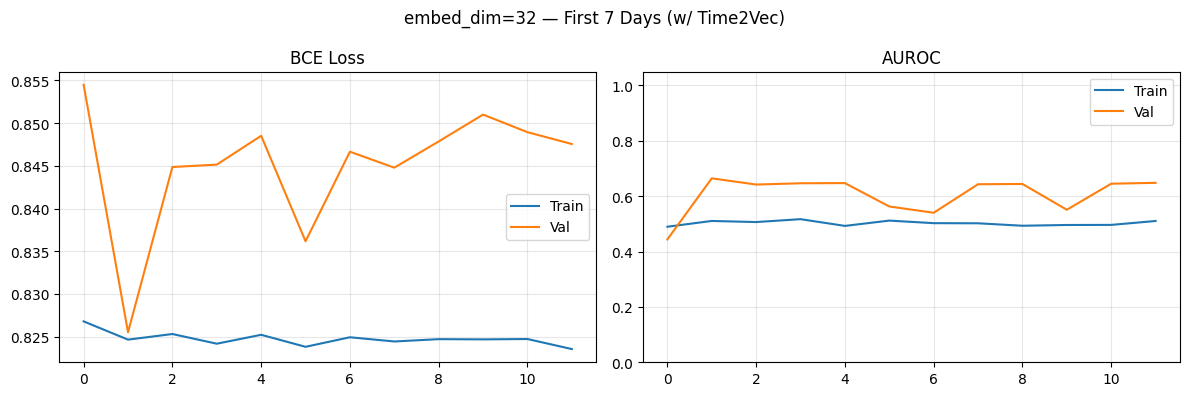

  Extracting embeddings (dim=32)...
  Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_32dim_withtime
  Train: (328, 35)  Val: (94, 35)  Test: (146, 35)

  EMBED_DIM = 64  |  nhead=4  |  hidden=256
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_64dim_withtime
  Parameters: 105,025

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

       1      0.8285     0.4958    0.8486   0.5962    89.2s  ✅


    Train:   0%|          | 0/390 [00:00<?]

...

    Val  :   0%|          | 0/100 [00:00<?]

      17      0.8243     0.4996    0.8479   0.4011    89.4s  


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

  Early stopping at epoch 18

  Best val AUROC (dim=64): 0.6471


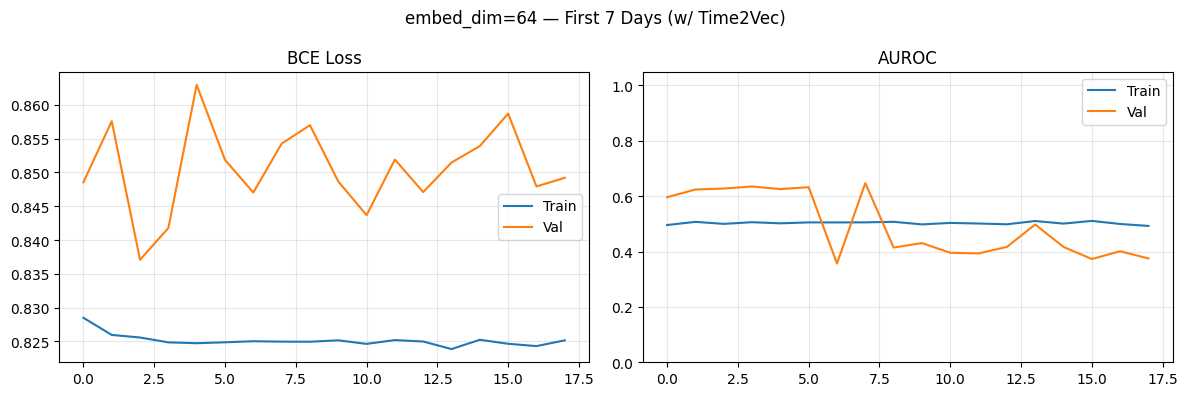

  Extracting embeddings (dim=64)...
  Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_64dim_withtime
  Train: (328, 67)  Val: (94, 67)  Test: (146, 67)

  EMBED_DIM = 128  |  nhead=4  |  hidden=512
  Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_128dim_withtime
  Parameters: 414,849

   Epoch  Train Loss  Train AUC  Val Loss  Val AUC     Time
  --------------------------------------------------------------


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

       1      0.8306     0.5031    0.8389   0.3640    95.3s  ✅


    Train:   0%|          | 0/390 [00:00<?]

...

    Val  :   0%|          | 0/100 [00:00<?]

      13      0.8261     0.5009    0.8491   0.5730    95.2s  


    Train:   0%|          | 0/390 [00:00<?]

    Val  :   0%|          | 0/100 [00:00<?]

  Early stopping at epoch 14

  Best val AUROC (dim=128): 0.6206


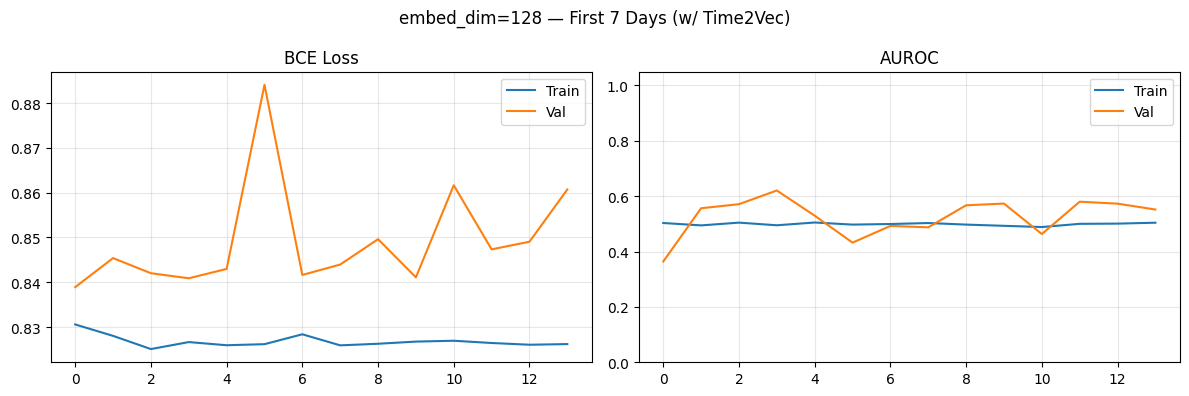

  Extracting embeddings (dim=128)...
  Embeddings saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_128dim_withtime
  Train: (328, 131)  Val: (94, 131)  Test: (146, 131)

FINAL SUMMARY — Best Val AUROC per embed_dim (w/ Time2Vec, First 7 Days)
  dim= 32: 0.6645  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_32dim_withtime
  dim= 64: 0.6471  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_64dim_withtime
  dim=128: 0.6206  → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_128dim_withtime


In [8]:
BASE_SAVE = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model"

DIM_CONFIGS = {
    32:  {'nhead': 4, 'hidden_dim': 128},
    64:  {'nhead': 4, 'hidden_dim': 256},
    128: {'nhead': 4, 'hidden_dim': 512},
}

# ── Functions defined OUTSIDE the loop ───────────────────────────────────────
def run_epoch(loader, model, optimizer, criterion, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    desc = 'Train' if train else 'Val  '
    with ctx:
        pbar = tqdm(loader, desc=f'    {desc}', leave=False,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
        for batch in pbar:
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ho  = batch['hour'].to(device)
            tfs = batch['time_from_start'].to(device)
            pm  = batch['padding_mask'].to(device)
            lbl = batch['label'].to(device)
            with autocast():
                _, logit = model(tt, tv, ho, tfs, pm)
                loss = criterion(logit.squeeze(1), lbl)
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
            total_loss += loss.item() * len(lbl)
            all_logits.append(logit.squeeze(1).detach().float().cpu())
            all_labels.append(lbl.cpu())
    all_logits = torch.cat(all_logits).sigmoid().numpy()
    all_labels = torch.cat(all_labels).numpy()
    avg_loss   = total_loss / len(all_labels)
    try:    auroc = roc_auc_score(all_labels, all_logits)
    except: auroc = float('nan')
    return avg_loss, auroc


def extract_embeddings(loader, model, device):
    accum = defaultdict(lambda: {'embs': [], 'label': None})
    with torch.no_grad():
        for batch in loader:
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ho  = batch['hour'].to(device)
            tfs = batch['time_from_start'].to(device)
            pm  = batch['padding_mask'].to(device)
            with autocast():
                emb, _ = model(tt, tv, ho, tfs, pm)
            emb_np = emb.float().cpu().numpy()
            for j in range(len(batch['label'])):
                key = (batch['patient_id'][j], batch['unified_day'][j])
                accum[key]['embs'].append(emb_np[j])
                accum[key]['label'] = int(batch['label'][j].item())
    records = []
    for (pid, uday), val in accum.items():
        mean_emb = np.mean(val['embs'], axis=0)
        row = {'patient_id': pid, 'unified_day': uday, 'label': val['label']}
        for k, v in enumerate(mean_emb):
            row[f'emb_{k}'] = float(v)
        records.append(row)
    return (pd.DataFrame(records)
            .sort_values(['patient_id', 'unified_day'])
            .reset_index(drop=True))


# ── Main loop ─────────────────────────────────────────────────────────────────
all_dim_results = {}

for EMBED_DIM, cfg in DIM_CONFIGS.items():
    print('\n' + '='*70)
    print(f'  EMBED_DIM = {EMBED_DIM}  |  nhead={cfg["nhead"]}  |  hidden={cfg["hidden_dim"]}')
    print('='*70)

    SAVE_DIR        = os.path.join(BASE_SAVE,
                          f'daily_embedding_classifier_first7days_{EMBED_DIM}dim_withtime')
    os.makedirs(SAVE_DIR, exist_ok=True)
    BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'best_day_embedding_transformer.pth')
    print(f'  Save dir: {SAVE_DIR}')

    model = DayEmbeddingTransformer(
        vocab_size=VOCAB_SIZE, pad_type_id=PAD_TYPE_ID,
        embed_dim=EMBED_DIM, nhead=cfg['nhead'],
        num_layers=2, hidden_dim=cfg['hidden_dim'], dropout=0.2,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parameters: {n_params:,}')

    train_labels = [s[2] for s in train_ds.samples]
    n_pos = sum(train_labels); n_neg = len(train_labels) - n_pos
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=10)
    scaler = GradScaler()

    NUM_EPOCHS = 100; EARLY_STOP_PAT = 10
    best_val_auroc = 0.0; early_stop_cnt = 0
    train_losses, val_losses, train_aurocs, val_aurocs = [], [], [], []

    print(f'\n  {"Epoch":>6}  {"Train Loss":>10}  {"Train AUC":>9}  '
          f'{"Val Loss":>8}  {"Val AUC":>7}  {"Time":>7}')
    print('  ' + '-'*62)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_auc = run_epoch(train_loader, model, optimizer,
                                    criterion, scaler, train=True)
        va_loss, va_auc = run_epoch(val_loader, model, optimizer,
                                    criterion, scaler, train=False)
        elapsed = time.time() - t0

        train_losses.append(tr_loss); val_losses.append(va_loss)
        train_aurocs.append(tr_auc);  val_aurocs.append(va_auc)
        scheduler.step(va_auc if not np.isnan(va_auc) else 0.0)

        marker = ''
        if (not np.isnan(va_auc)) and va_auc > best_val_auroc:
            best_val_auroc = va_auc
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            early_stop_cnt = 0; marker = '✅'
        else:
            early_stop_cnt += 1
            if early_stop_cnt >= EARLY_STOP_PAT:
                print(f'  Early stopping at epoch {epoch}'); break

        va_str = f'{va_auc:.4f}' if not np.isnan(va_auc) else '   nan'
        print(f'  {epoch:>6}  {tr_loss:>10.4f}  {tr_auc:>9.4f}  '
              f'{va_loss:>8.4f}  {va_str:>7}  {elapsed:>6.1f}s  {marker}')

    print(f'\n  Best val AUROC (dim={EMBED_DIM}): {best_val_auroc:.4f}')

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'embed_dim={EMBED_DIM} — First 7 Days (w/ Time2Vec)', fontsize=12)
    axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Val')
    axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(train_aurocs, label='Train'); axes[1].plot(val_aurocs, label='Val')
    axes[1].set_title('AUROC'); axes[1].set_ylim(0, 1.05)
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
    plt.show()

    # Extract embeddings
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval()
    print(f'  Extracting embeddings (dim={EMBED_DIM})...')
    emb_train = extract_embeddings(train_loader, model, device)
    emb_val   = extract_embeddings(val_loader,   model, device)
    emb_test  = extract_embeddings(test_loader,  model, device)

    emb_train.to_parquet(os.path.join(SAVE_DIR, 'emb_train.parquet'), index=False)
    emb_val.to_parquet(  os.path.join(SAVE_DIR, 'emb_val.parquet'),   index=False)
    emb_test.to_parquet( os.path.join(SAVE_DIR, 'emb_test.parquet'),  index=False)
    print(f'  Embeddings saved → {SAVE_DIR}')
    print(f'  Train: {emb_train.shape}  Val: {emb_val.shape}  Test: {emb_test.shape}')

    all_dim_results[EMBED_DIM] = {
        'best_val_auroc': best_val_auroc,
        'save_dir': SAVE_DIR,
        'emb_train': emb_train, 'emb_val': emb_val, 'emb_test': emb_test,
    }
    del model; gc.collect(); torch.cuda.empty_cache()

print('\n' + '='*50)
print('FINAL SUMMARY — Best Val AUROC per embed_dim (w/ Time2Vec, First 7 Days)')
print('='*50)
for dim, res in all_dim_results.items():
    print(f'  dim={dim:>3}: {res["best_val_auroc"]:.4f}  → {res["save_dir"]}')


In [9]:
# Training curves are now saved inside the dim loop above (Step 7).
# This cell is kept as a placeholder — nothing to run here.
print('Training curves saved per dim inside the loop.')


Training curves saved per dim inside the loop.
